# ENSIA Amphitheatre GPS Localization using Hidden Markov Models

This notebook implements a Hidden Markov Model (HMM) approach to predict the amphitheatre location (or outdoor status) from GPS sequences.

## Problem Overview

Students submit GPS readings while in one of 8 amphitheatres (Amphi 1-8) or outside. Each submission contains a sequence of raw GPS pings. The goal is to predict the correct location from the GPS signal sequence.

**Why HMM?**
- True location is a hidden state
- GPS readings are sequential observations
- Location is persistent within a session

## HMM Formulation

- **States (S):** Amphi 1, Amphi 2, ..., Amphi 8, Outside (9 states)
- **Observations (O):** [latitude, longitude, accuracy] vectors
- **Approach:** Per-class HMMs (one GaussianHMM per location)

## 1. Imports and Setup

In [2]:
%pip install hmmlearn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import json
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn.hmm import GaussianHMM
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

## 2. Data Loading and Preprocessing

Load the dataset, parse JSON readings, encode labels, and normalize features.

In [5]:
def load_and_clean(csv_path: str, test_size: float = 0.2):
    """
    Load and preprocess the GPS dataset.
    """
    # Read CSV
    df = pd.read_csv(csv_path)

    # Parse RawReadings JSON
    df["RawReadings"] = df["RawReadings"].apply(json.loads)

    # Filter out empty or short sequences
    df = df[df["RawReadings"].apply(len) >= 2]

    # Adjust labels: assuming Amphi 1-8 and Outside
    # If dataset has Amphi 1-7, we need to handle Amphi 8
    # For now, assume labels are Amphi 1-8 and Outside
    label_mapping = {
        'Amphi 1': 'Amphi 1', 'Amphi 2': 'Amphi 2', 'Amphi 3': 'Amphi 3',
        'Amphi 4': 'Amphi 4', 'Amphi 5': 'Amphi 5', 'Amphi 6': 'Amphi 6',
        'Amphi 7': 'Amphi 7', 'Amphi 8': 'Amphi 8', 'Outside': 'Outside'
    }
    df['Amphi'] = df['Amphi'].map(label_mapping).fillna('Outside')  # Default to Outside if unknown

    # Encode labels
    label_encoder = LabelEncoder()
    df['label'] = label_encoder.fit_transform(df['Amphi'])

    # Check if stratification is possible (all classes must have at least 2 samples)
    class_counts = df['label'].value_counts()
    can_stratify = class_counts.min() >= 2

    # Split train/test before scaling
    if can_stratify:
        df_train, df_test = train_test_split(df, test_size=test_size, random_state=42, stratify=df['label'])
    else:
        print("Warning: Some classes have fewer than 2 samples. Using random split without stratification.")
        df_train, df_test = train_test_split(df, test_size=test_size, random_state=42)

    # Fit scaler on training data only
    scaler = StandardScaler()
    # We don't have global features to scale here, scaling will be done per sequence

    return df_train, df_test, label_encoder, scaler

# Load data
csv_path = "../../Data/ensia_gps_data .csv"  # Adjust path as needed
df_train, df_test, label_encoder, scaler = load_and_clean(csv_path)

print(f"Training samples: {len(df_train)}")
print(f"Test samples: {len(df_test)}")
print(f"Classes: {label_encoder.classes_}")
print(f"Class distribution (train): {Counter(df_train['Amphi'])}")

Training samples: 32
Test samples: 9
Classes: ['Amphi 1' 'Amphi 2' 'Amphi 3' 'Amphi 4' 'Amphi 5' 'Amphi 6' 'Amphi 7'
 'Outside']
Class distribution (train): Counter({'Amphi 7': 10, 'Amphi 6': 6, 'Outside': 6, 'Amphi 5': 4, 'Amphi 1': 3, 'Amphi 2': 2, 'Amphi 4': 1})


## 3. Sequence Construction

Convert each submission into observation sequences for HMM training.

In [6]:
def build_sequences(df: pd.DataFrame, scaler: StandardScaler = None) -> tuple[list, list, np.ndarray]:
    """
    Build observation sequences from dataframe.
    Each sequence is (T, 3) where T is number of GPS pings.
    """
    sequences, lengths, labels = [], [], []

    for _, row in df.iterrows():
        pings = row["RawReadings"]
        # Extract lat, lng, accuracy
        obs = np.array([[p["latitude"], p["longitude"], p["accuracy_m"]] for p in pings])

        # Normalize if scaler provided
        if scaler is not None:
            obs = scaler.transform(obs)  # Use transform, not fit_transform

        sequences.append(obs)
        lengths.append(len(obs))
        labels.append(row["label"])

    return sequences, lengths, np.array(labels)

# Build sequences for train and test
# First, collect all training observations to fit scaler
all_train_obs = []
for _, row in df_train.iterrows():
    pings = row["RawReadings"]
    obs = np.array([[p["latitude"], p["longitude"], p["accuracy_m"]] for p in pings])
    all_train_obs.append(obs)

all_train_concat = np.concatenate(all_train_obs, axis=0)
scaler.fit(all_train_concat)

# Now build sequences with fitted scaler
train_sequences, train_lengths, train_labels = build_sequences(df_train, scaler)
test_sequences, test_lengths, test_labels = build_sequences(df_test, scaler)

print(f"Number of training sequences: {len(train_sequences)}")
print(f"Number of test sequences: {len(test_sequences)}")
print(f"Average sequence length (train): {np.mean(train_lengths):.1f}")
print(f"Average sequence length (test): {np.mean(test_lengths):.1f}")

Number of training sequences: 32
Number of test sequences: 9
Average sequence length (train): 11.2
Average sequence length (test): 10.7


## 4. Model Definition

Define the HMM architecture: one GaussianHMM per class.

In [7]:
def build_model(n_states: int = 1, covariance_type: str = "full", n_iter: int = 100):
    """
    Build a Gaussian HMM model.
    For per-class approach, n_states=1 (single state per class).
    """
    return GaussianHMM(
        n_components=n_states,
        covariance_type=covariance_type,
        n_iter=n_iter,
        init_params="stmc",  # let hmmlearn initialize s, t, m, c
        params="stmc",       # learn all parameters
        random_state=42,
    )

# We use one state per class (generative per-class models)
n_states_per_model = 1
covariance_type = "full"  # or "diag" if data is sparse
n_iter = 100

## 5. Training

Train one HMM per class using Baum-Welch algorithm.

In [8]:
def train_per_class_models(sequences, lengths, labels, n_states=1, covariance_type="full", n_iter=100):
    """
    Train one HMM per class.
    """
    models = {}
    unique_classes = np.unique(labels)

    for c in unique_classes:
        print(f"Training model for class {c} ({label_encoder.inverse_transform([c])[0]})...")

        # Filter sequences for this class
        mask = labels == c
        seqs_c = [sequences[i] for i in range(len(sequences)) if mask[i]]
        lens_c = [lengths[i] for i in range(len(lengths)) if mask[i]]

        if len(seqs_c) == 0:
            print(f"No sequences for class {c}, skipping...")
            continue

        # Concatenate sequences
        X_c = np.concatenate(seqs_c, axis=0)

        # Build and fit model
        model = build_model(n_states=n_states, covariance_type=covariance_type, n_iter=n_iter)
        model.fit(X_c, lens_c)

        models[c] = model
        print(f"  Trained on {len(seqs_c)} sequences, total length {len(X_c)}")

    return models

# Train models
models = train_per_class_models(train_sequences, train_lengths, train_labels,
                               n_states=n_states_per_model,
                               covariance_type=covariance_type,
                               n_iter=n_iter)

print(f"\nTrained {len(models)} models")

Training model for class 0 (Amphi 1)...
  Trained on 3 sequences, total length 32
Training model for class 1 (Amphi 2)...


  File "c:\Users\ASUS\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\ASUS\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ASUS\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ASUS\anaconda3\Lib\subprocess.py",

  Trained on 2 sequences, total length 20
Training model for class 3 (Amphi 4)...
  Trained on 1 sequences, total length 10
Training model for class 4 (Amphi 5)...
  Trained on 4 sequences, total length 45
Training model for class 5 (Amphi 6)...
  Trained on 6 sequences, total length 81
Training model for class 6 (Amphi 7)...
  Trained on 10 sequences, total length 112
Training model for class 7 (Outside)...
  Trained on 6 sequences, total length 60

Trained 7 models


## 6. Prediction

Predict amphitheatre labels for test sequences by scoring against all models.

In [9]:
def predict_sequence(obs: np.ndarray, models: dict) -> int:
    """
    Predict class for a single observation sequence.
    """
    scores = {}
    for c, model in models.items():
        try:
            score = model.score(obs)
            scores[c] = score
        except:
            # If scoring fails (e.g., sequence too short), assign low score
            scores[c] = -np.inf

    # Return class with highest score
    return max(scores, key=scores.get)

def predict_batch(sequences: list, models: dict) -> np.ndarray:
    """
    Predict classes for a batch of sequences.
    """
    predictions = []
    for obs in sequences:
        pred = predict_sequence(obs, models)
        predictions.append(pred)
    return np.array(predictions)

# Make predictions on test set
y_pred = predict_batch(test_sequences, models)

print(f"Predictions completed for {len(y_pred)} test sequences")

Predictions completed for 9 test sequences


In [ ]:
# Make predictions on training set for evaluation
y_pred_train = predict_batch(train_sequences, models)

print(f"Training predictions completed for {len(y_pred_train)} sequences")

# Evaluate on training set
evaluate(train_labels, y_pred_train, label_encoder, save_path="../../figures/confusion_matrix_train.png")

## 7. Evaluation

Evaluate the model performance with classification metrics and confusion matrix.

Classification Report:
              precision    recall  f1-score   support

     Amphi 1       1.00      1.00      1.00         1
     Amphi 2       0.00      0.00      0.00         1
     Amphi 3       0.00      0.00      0.00         1
     Amphi 5       0.00      0.00      0.00         1
     Amphi 6       0.67      1.00      0.80         2
     Amphi 7       0.40      1.00      0.57         2
     Outside       0.00      0.00      0.00         1

    accuracy                           0.56         9
   macro avg       0.30      0.43      0.34         9
weighted avg       0.35      0.56      0.42         9



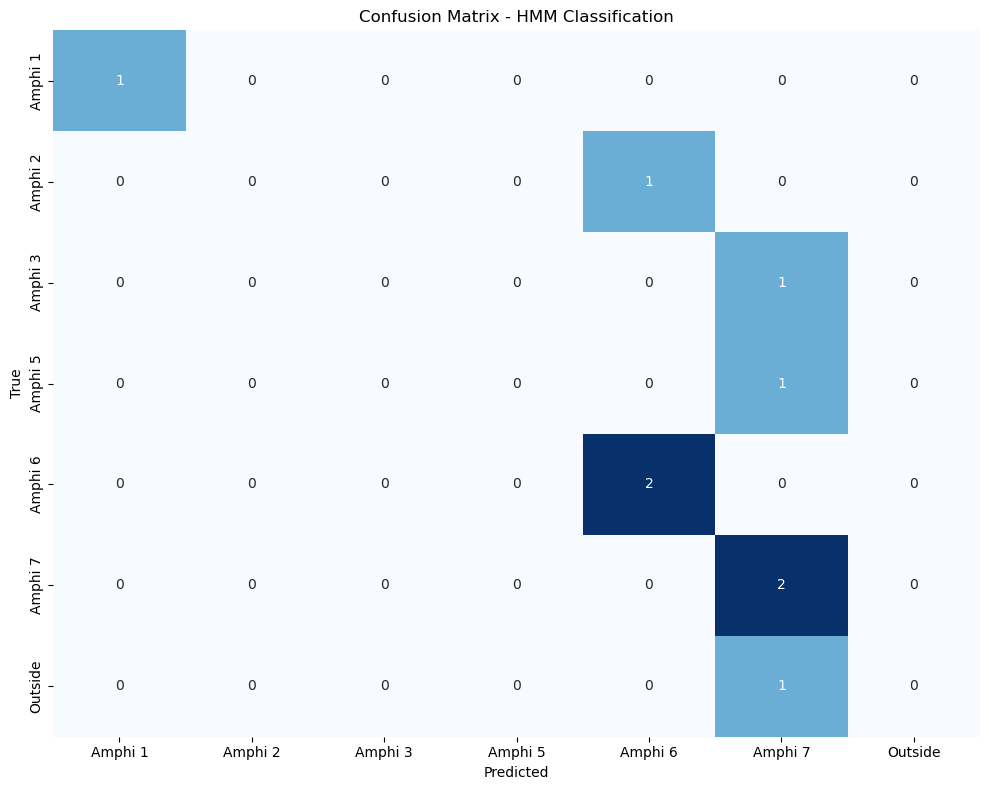

Confusion matrix saved to ../../figures/confusion_matrix.png


In [ ]:
# Evaluate on test set
evaluate(test_labels, y_pred, label_encoder, save_path="../../figures/confusion_matrix_test.png")

## Summary

This notebook implements a complete HMM-based GPS localization system:

1. **Data Loading**: Parsed JSON GPS sequences and encoded 9 location classes (Amphi 1-8 + Outside)
2. **Preprocessing**: Normalized GPS features and built observation sequences
3. **Model**: Used per-class Gaussian HMMs (one per location)
4. **Training**: Applied Baum-Welch algorithm to learn emission parameters
5. **Prediction**: Scored test sequences against all models for classification
6. **Evaluation**: Computed accuracy, precision/recall/F1, and confusion matrices for both training and test sets

The HMM approach leverages temporal dependencies in GPS sequences for improved localization accuracy compared to single-point classification.